In [ ]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import pandas as pd
from IPython.display import display


def find_project_root(start: Path) -> Path:
    for candidate in (start.resolve(), *start.resolve().parents):
        if all((candidate / name).exists() for name in ("research", "configs", "runs")):
            return candidate
    raise FileNotFoundError("C:/ronbun 내부에서 노트북을 실행하십시오.")


def load_json(path: Path) -> dict:
    return json.loads(path.read_text(encoding="utf-8"))


PROJECT_ROOT = find_project_root(Path.cwd())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# 사용자 선택 영역: 모델·데이터셋·완료 run만 바꾸고 아래 로직은 수정하지 않습니다.
MODEL_NAME = globals().get("MODEL_NAME", "arcface")
DATASETS = tuple(globals().get("DATASETS", ("lfw", "survface")))
if MODEL_NAME not in {"arcface", "adaface", "magface"}:
    raise ValueError(f"지원하지 않는 MODEL_NAME: {MODEL_NAME!r}")
if not DATASETS or not set(DATASETS).issubset({"lfw", "survface"}):
    raise ValueError(f"지원하지 않는 DATASETS: {DATASETS!r}")

# 기존 셀에서 RUN_IDS로 불렀던 adaface-... 값은 model_uid입니다.
MODEL_UIDS = dict(globals().get("MODEL_UIDS", {
    "lfw": "arcface-7972a704552df378345f",
    "survface": "arcface-7972a704552df378345f",
}))
# 아래 값은 실제 Step 4 workflow run_id입니다.
RUN_IDS = dict(globals().get("RUN_IDS", {
    "lfw": "20260803-R001-a4479011",
    "survface": "20260803-R001-33efcd08",
}))







CHUNKSIZE = 100_000
PREFER_MATCHED_CALIBRATION_SEARCH_SPACE = True  # 3,000-ID calibration v3 우선
INCLUDE_SURVFACE_FAITHFULNESS = bool(globals().get("INCLUDE_SURVFACE_FAITHFULNESS", True))  # 3-model high/low/random occlusion table
REBUILD_DATASET_SUMMARIES = False  # legacy 대용량 원본에서 다시 집계
VERIFY_SOURCE_SHA256 = False       # True이면 수 GB 원본 SHA-256까지 재검증
DEFAULT_WRITE_OUTPUTS = True
WRITE_OUTPUTS = bool(globals().get("WRITE_OUTPUTS", DEFAULT_WRITE_OUTPUTS))
OVERWRITE_COMMON_OUTPUTS = bool(globals().get("OVERWRITE_COMMON_OUTPUTS", True))

required_relative_paths = (
    Path("COMPLETED"),
    Path("artifacts/step2_workflow/freeze_manifest.json"),
    Path("artifacts/step2_workflow/step4_summary.json"),
    Path("artifacts/step2_workflow/paired_embedding_metrics.csv"),
    Path("artifacts/step2_workflow/retrieval_metrics.csv"),
)
candidate_rows = []
for manifest_path in sorted((PROJECT_ROOT / "runs").rglob("run_manifest.json")):
    run_dir = manifest_path.parent
    freeze_path = run_dir / "artifacts/step2_workflow/freeze_manifest.json"
    step4_path = run_dir / "artifacts/step2_workflow/step4_summary.json"
    if not freeze_path.is_file() or not step4_path.is_file():
        continue
    run_manifest = load_json(manifest_path)
    freeze = load_json(freeze_path)
    step4 = load_json(step4_path)
    model_uid = str(freeze.get("model_uid", ""))
    dataset = str(freeze.get("dataset_id", ""))
    ready = (
        run_manifest.get("status") == "completed"
        and freeze.get("fallback_free") is True
        and all((run_dir / path).exists() for path in required_relative_paths)
        and str(run_manifest.get("run_id")) == str(freeze.get("run_id"))
        and str(step4.get("run_id")) == str(freeze.get("run_id"))
    )
    paired_path = run_dir / "artifacts/step2_workflow/paired_embedding_metrics.csv"
    retrieval_path = run_dir / "artifacts/step2_workflow/retrieval_metrics.csv"
    candidate_rows.append(
        {
            "dataset": dataset,
            "model_name": model_uid.split("-", 1)[0].lower(),
            "model_uid": model_uid,
            "run_id": str(run_manifest.get("run_id", "")),
            "status": run_manifest.get("status"),
            "ready": ready,
            "mode": freeze.get("scope", {}).get("mode"),
            "data_fraction": freeze.get("scope", {}).get("data_fraction"),
            "is_paper_run": freeze.get("scope", {}).get("is_paper_run"),
            "selected_samples": step4.get("selected_samples"),
            "paired_rows": step4.get("paired_rows"),
            "retrieval_rows": step4.get("retrieval_rows"),
            "source_gib": round(
                sum(
                    path.stat().st_size if path.exists() else 0
                    for path in (paired_path, retrieval_path)
                )
                / (1024**3),
                3,
            ),
            "source_branch": run_manifest.get("git", {}).get("branch"),
            "source_commit": run_manifest.get("git", {}).get("commit"),
            "run_dir": run_dir.relative_to(PROJECT_ROOT).as_posix(),
        }
    )

EXPERIMENT_CANDIDATES = pd.DataFrame.from_records(candidate_rows)
if EXPERIMENT_CANDIDATES.empty:
    raise FileNotFoundError("완료된 Step 4 후보를 조회할 수 없습니다.")
EXPERIMENT_CANDIDATES = EXPERIMENT_CANDIDATES.sort_values(
    ["dataset", "model_name", "run_id"]
).reset_index(drop=True)
display(EXPERIMENT_CANDIDATES)

RUN_SELECTORS = {}
try:
    import ipywidgets as widgets

    for dataset in DATASETS:
        choices = EXPERIMENT_CANDIDATES.loc[
            EXPERIMENT_CANDIDATES["ready"]
            & EXPERIMENT_CANDIDATES["dataset"].eq(dataset)
            & EXPERIMENT_CANDIDATES["model_name"].eq(MODEL_NAME)
            & EXPERIMENT_CANDIDATES["model_uid"].eq(MODEL_UIDS[dataset])
        ]
        options = [
            (
                f"{row.run_id} | {row.model_uid} | {row.mode} "
                f"p={row.data_fraction}",
                row.run_id,
            )
            for row in choices.itertuples(index=False)
        ]
        values = {value for _, value in options}
        if RUN_IDS[dataset] not in values:
            raise ValueError(
                f"{dataset}: configured run_id {RUN_IDS[dataset]!r}가 "
                "조회된 완료 후보에 없습니다."
            )
        RUN_SELECTORS[dataset] = widgets.Dropdown(
            options=options,
            value=RUN_IDS[dataset],
            description=dataset,
            layout=widgets.Layout(width="900px"),
            style={"description_width": "100px"},
        )
    display(widgets.VBox(list(RUN_SELECTORS.values())))
    print("드롭다운을 변경한 뒤 다음 셀부터 실행하십시오.")
except ImportError:
    print("ipywidgets가 없어 RUN_IDS 설정값을 사용합니다.")
    display(pd.Series(RUN_IDS, name="selected_run_id").to_frame())


,dataset,model_name,model_uid,run_id,status,ready,mode,data_fraction,is_paper_run,selected_samples,paired_rows,retrieval_rows,source_gib,source_branch,source_commit,run_dir
0,lfw,adaface,adaface-4df25b75e065b0b9ed43,20260804-R001-60fc86b5,completed,True,real,1.0,True,13195,131950,75740,0.270,step6,f9ac98001ec0452017f60411c70a391d2d2ab113,runs/lfw_20260804/20260804-R001-60fc86b5_step4...
1,lfw,arcface,arcface-7972a704552df378345f,20260803-R001-a4479011,completed,True,real,1.0,True,13195,131950,75740,0.270,step6,e85a07582d77f7df404b9ad819e84d4d4afa8ab9,runs/lfw_20260803/20260803-R001-a4479011_step4...
2,lfw,magface,magface-6931178ad2025e1b3799,20260804-R001-325af0c4,completed,True,real,1.0,True,13195,131950,75740,0.269,step6,6c977210a2c1e3e02eaa20c23f8baa1586cfe4af,runs/lfw_20260804/20260804-R001-325af0c4_step4...
3,survface,adaface,adaface-4df25b75e065b0b9ed43,20260804-R001-f60c9930,completed,True,real,1.0,True,463341,4633410,6375565,24.635,step6,f9ac98001ec0452017f60411c70a391d2d2ab113,runs/survface_20260804/20260804-R001-f60c9930_...
4,survface,arcface,arcface-7972a704552df378345f,20260803-R001-33efcd08,completed,True,real,1.0,True,463341,4633410,6375565,24.628,step6,04ca54f8b34759ba09cd48996bd568523183dd2e,runs/survface_20260803/20260803-R001-33efcd08_...
5,survface,magface,magface-6931178ad2025e1b3799,20260804-R001-4d8260d6,completed,True,real,1.0,True,463341,4633410,6375565,24.622,step6,6c977210a2c1e3e02eaa20c23f8baa1586cfe4af,runs/survface_20260804/20260804-R001-4d8260d6_...


드롭다운을 변경한 뒤 다음 셀부터 실행하십시오.


# 모델·데이터셋 선택형 compact 실험 결과 보고서

완료된 fallback-free Step 4 실행만 선택하여 다음 산출물을 만듭니다.

- 데이터셋별 `compression_summary.csv`: compression family/profile당 1행
- 데이터셋별 `retrieval_summary.csv`: family/profile/search mode/threshold policy당 1행
- 공통 `compression_summary_all.csv`: 위 두 표를 검증된 provenance key로 결합한 최종 비교표

이 노트북은 모델·데이터셋·완료 run을 선택해 canonical artifact를 검증·집계하는 얇은 보고 인터페이스입니다. 압축 또는 검색 실험 로직은 `research/`와 `scripts/`에 두며, 대용량 원본 ledger는 공통 출력에 복제하지 않습니다.


In [10]:
from scripts.generate_step4_compact_summaries import generate
from research.runtime.hashing import sha256_file

SELECTED_RUN_IDS = {
    dataset: RUN_SELECTORS[dataset].value if RUN_SELECTORS else RUN_IDS[dataset]
    for dataset in DATASETS
}

selected_rows = []
SELECTED_RUNS = {}
for dataset in DATASETS:
    matches = EXPERIMENT_CANDIDATES.loc[
        EXPERIMENT_CANDIDATES["ready"]
        & EXPERIMENT_CANDIDATES["dataset"].eq(dataset)
        & EXPERIMENT_CANDIDATES["model_name"].eq(MODEL_NAME)
        & EXPERIMENT_CANDIDATES["model_uid"].eq(MODEL_UIDS[dataset])
        & EXPERIMENT_CANDIDATES["run_id"].eq(SELECTED_RUN_IDS[dataset])
    ]
    if len(matches) != 1:
        raise ValueError(
            f"{dataset}: 선택 조건과 일치하는 완료 실행이 1개가 아닙니다: {len(matches)}"
        )
    row = matches.iloc[0]
    run_dir = PROJECT_ROOT / str(row["run_dir"])
    SELECTED_RUNS[dataset] = run_dir
    selected_rows.append(row)

selected_run_table = pd.DataFrame(selected_rows).reset_index(drop=True)
if set(selected_run_table["model_name"]) != {MODEL_NAME}:
    raise ValueError("선택 실행의 model_name이 MODEL_NAME과 일치하지 않습니다.")
display(selected_run_table)

SURVFACE_ORIGIN_AUDIT = pd.DataFrame()
SURVFACE_CALIBRATION_TRANSFER_FAILED = None
cross_model_audit_path = (
    PROJECT_ROOT / "runs/survface_origin_fpir_diagnostics"
    / "20260802_cross_model_summary_v1/cross_model_origin_fpir_summary.csv"
)
if "survface" in DATASETS and cross_model_audit_path.is_file():
    cross_model_audit = pd.read_csv(cross_model_audit_path)
    SURVFACE_ORIGIN_AUDIT = cross_model_audit.loc[
        cross_model_audit["model_uid"].eq(MODEL_UIDS["survface"])
        & cross_model_audit["source_run_id"].eq(SELECTED_RUN_IDS["survface"])
    ].copy()
    if not SURVFACE_ORIGIN_AUDIT.empty:
        SURVFACE_CALIBRATION_TRANSFER_FAILED = bool(
            (SURVFACE_ORIGIN_AUDIT["test_fpir"] > SURVFACE_ORIGIN_AUDIT["target_fpir"]).any()
        )
        display(
            SURVFACE_ORIGIN_AUDIT[[
                "model_family", "calibration_condition_uid",
                "calibration_fpir", "matched_test_fpir", "test_fpir",
                "test_to_target_fpir_ratio",
            ]]
        )
        if SURVFACE_CALIBRATION_TRANSFER_FAILED:
            print("WARNING: SurvFace threshold-dependent claim은 calibration transfer 실패로 보류됩니다.")


,dataset,model_name,model_uid,run_id,status,ready,mode,data_fraction,is_paper_run,selected_samples,paired_rows,retrieval_rows,source_gib,source_branch,source_commit,run_dir
0,lfw,arcface,arcface-7972a704552df378345f,20260803-R001-a4479011,completed,True,real,1.0,True,13195,131950,75740,0.270,step6,e85a07582d77f7df404b9ad819e84d4d4afa8ab9,runs/lfw_20260803/20260803-R001-a4479011_step4...
1,survface,arcface,arcface-7972a704552df378345f,20260803-R001-33efcd08,completed,True,real,1.0,True,463341,4633410,6375565,24.628,step6,04ca54f8b34759ba09cd48996bd568523183dd2e,runs/survface_20260803/20260803-R001-33efcd08_...


## 1. 데이터셋별 compact summary 생성·검증

`PREFER_MATCHED_CALIBRATION_SEARCH_SPACE=True`이고 검증된 `search_space_v3_matched_calibration`이 있으면 3,000-ID half-gallery calibration의 PCA direct/reconstruction과 PQ reconstruction/ADC summary를 우선 사용합니다. 없으면 기존 `search_space_v2`, 그다음 legacy summary를 검증해 재사용합니다.


In [11]:
def resolve_manifest_path(recorded_path: str) -> Path:
    path = Path(recorded_path)
    return path if path.is_absolute() else PROJECT_ROOT / path


def validate_summary_bundle(
    summary_dir: Path,
    *,
    dataset: str,
    run_dir: Path,
) -> dict:
    manifest_path = summary_dir / "summary_manifest.json"
    if not manifest_path.is_file():
        raise FileNotFoundError(manifest_path)
    payload = load_json(manifest_path)
    artifact_type = str(payload.get("artifact_type", ""))
    supported_artifacts = {
        "step4_compact_summaries",
        "step4_search_space_refresh",
    }
    if artifact_type not in supported_artifacts:
        raise ValueError(f"{dataset}: unsupported summary artifact: {artifact_type!r}")
    expected_identity = {
        "dataset_id": dataset,
        "model_uid": MODEL_UIDS[dataset],
        "run_id": SELECTED_RUN_IDS[dataset],
    }
    if artifact_type == "step4_compact_summaries":
        expected_identity["source_run_status"] = "completed"
    else:
        expected_identity["source_run_id"] = SELECTED_RUN_IDS[dataset]
        if payload.get("source_run_preserved_immutable") is not True:
            raise ValueError(f"{dataset}: derived summary did not preserve source run")
    mismatches = {
        key: (payload.get(key), expected)
        for key, expected in expected_identity.items()
        if payload.get(key) != expected
    }
    if mismatches:
        raise ValueError(f"{dataset}: summary identity mismatch: {mismatches}")

    source_manifest = payload.get("source_files", {}).get("run_manifest.json", {})
    recorded_source = resolve_manifest_path(str(source_manifest.get("path", "")))
    if recorded_source.resolve() != (run_dir / "run_manifest.json").resolve():
        raise ValueError(f"{dataset}: summary가 선택하지 않은 source run을 참조합니다.")

    output_files = payload.get("output_files", {})
    if set(output_files) != {"compression_summary.csv", "retrieval_summary.csv"}:
        raise ValueError(f"{dataset}: summary output file contract mismatch")
    for name, metadata in output_files.items():
        path = summary_dir / name
        if not path.is_file():
            raise FileNotFoundError(path)
        if path.stat().st_size != int(metadata["bytes"]):
            raise ValueError(f"{dataset}/{name}: byte-size mismatch")
        if sha256_file(path) != metadata["sha256"]:
            raise ValueError(f"{dataset}/{name}: SHA-256 mismatch")

    if VERIFY_SOURCE_SHA256:
        for name, metadata in payload.get("source_files", {}).items():
            path = resolve_manifest_path(str(metadata["path"]))
            if path.stat().st_size != int(metadata["bytes"]):
                raise ValueError(f"{dataset}/{name}: source byte-size mismatch")
            if sha256_file(path) != metadata["sha256"]:
                raise ValueError(f"{dataset}/{name}: source SHA-256 mismatch")
    return payload


SUMMARY_DIRS = {}
SUMMARY_MANIFESTS = {}
generation_rows = []
for dataset, run_dir in SELECTED_RUNS.items():
    result_base = (
        PROJECT_ROOT
        / "results"
        / "paper"
        / dataset
        / SELECTED_RUN_IDS[dataset]
    )
    matched_search_space_dir = (
        result_base / "search_space_v3_matched_calibration"
    )
    legacy_search_space_dir = result_base / "search_space_v2"
    legacy_summary_dir = result_base / "summaries"
    use_matched_search_space = bool(
        PREFER_MATCHED_CALIBRATION_SEARCH_SPACE
        and (matched_search_space_dir / "summary_manifest.json").is_file()
    )
    use_legacy_search_space = bool(
        not use_matched_search_space
        and (legacy_search_space_dir / "summary_manifest.json").is_file()
    )
    use_search_space = use_matched_search_space or use_legacy_search_space
    summary_dir = (
        matched_search_space_dir
        if use_matched_search_space
        else legacy_search_space_dir
        if use_legacy_search_space
        else legacy_summary_dir
    )
    SUMMARY_DIRS[dataset] = summary_dir
    expected_outputs = tuple(
        summary_dir / name
        for name in (
            "compression_summary.csv",
            "retrieval_summary.csv",
            "summary_manifest.json",
        )
    )
    present_count = sum(path.exists() for path in expected_outputs)
    should_generate = (not use_search_space) and (
        REBUILD_DATASET_SUMMARIES or present_count == 0
    )
    if 0 < present_count < len(expected_outputs) and not REBUILD_DATASET_SUMMARIES:
        raise RuntimeError(
            f"{dataset}: 일부 summary만 존재합니다. 원인을 확인한 뒤 "
            "REBUILD_DATASET_SUMMARIES=True로 재생성하십시오."
        )
    if should_generate:
        result = generate(
            run_dir,
            summary_dir,
            chunksize=CHUNKSIZE,
            overwrite=REBUILD_DATASET_SUMMARIES,
        )
        action = "generated"
    else:
        result = {"output_dir": str(summary_dir)}
        action = (
            "reused_search_space_v3_matched_calibration"
            if use_matched_search_space
            else "reused_search_space_v2"
            if use_legacy_search_space
            else "reused_legacy"
        )
    payload = validate_summary_bundle(
        summary_dir,
        dataset=dataset,
        run_dir=run_dir,
    )
    SUMMARY_MANIFESTS[dataset] = payload
    generation_rows.append(
        {
            "dataset": dataset,
            "action": action,
            "run_id": payload["run_id"],
            "model_uid": payload["model_uid"],
            "artifact_type": payload["artifact_type"],
            "claim_status": payload.get("claim_status", "legacy_source_run"),
            **payload["validated_counts"],
            "summary_dir": summary_dir.relative_to(PROJECT_ROOT).as_posix(),
        }
    )

if "survface" in SUMMARY_MANIFESTS:
    matched_signature = SUMMARY_MANIFESTS["survface"].get(
        "origin_calibration_signature", {}
    )
    if matched_signature.get("threshold_selection") == (
        "non-mated maximum-score empirical FPIR only; most permissive "
        "tie-preserving threshold within target"
    ):
        SURVFACE_CALIBRATION_TRANSFER_FAILED = (
            matched_signature.get("status") != "target_met"
        )
        print(
            "SurvFace matched calibration status:",
            matched_signature.get("status"),
            "test_fpir=", matched_signature.get("test_fpir"),
        )
generation_table = pd.DataFrame(generation_rows)
display(generation_table)


SurvFace matched calibration status: target_met test_fpir= 0.09269238351843333


,dataset,action,run_id,model_uid,artifact_type,claim_status,compression_summary_rows,retrieval_summary_rows,summary_dir
0,lfw,reused_search_space_v2,20260803-R001-a4479011,arcface-7972a704552df378345f,step4_search_space_refresh,exploratory_dirty_evaluator,10,35,results/paper/lfw/20260803-R001-a4479011/searc...
1,survface,reused_search_space_v3_matched_calibration,20260803-R001-33efcd08,arcface-7972a704552df378345f,step4_search_space_refresh,validation_required,10,35,results/paper/survface/20260803-R001-33efcd08/...


## 2. 두 summary의 schema·값 범위 검증과 결합

결합 grain은 dataset/model/run/compression profile/search mode/threshold policy당 1행입니다. PCA direct/reconstruction과 PQ reconstruction/ADC를 합치지 않으며, 압축 오차와 검색 지표는 명시적 provenance key와 `many_to_one` 검증으로만 결합합니다.


In [12]:
def normalize_retrieval_summary(frame: pd.DataFrame) -> pd.DataFrame:
    result = frame.copy()
    if "search_mode" not in result:
        result["search_mode"] = result["compression_family"].map(
            {"pca": "pca_direct_cosine", "pq": "pq_reconstruction_cosine"}
        )
    defaults = {
        "origin_score_space": "cosine_similarity",
        "compressed_score_space": "cosine_similarity",
        "score_spaces_comparable": True,
        "frozen_origin_threshold_applicable": True,
        "gallery_template_count": pd.NA,
        "origin_storage_bytes_per_embedding": 512 * 4,
        "origin_gallery_storage_bytes": pd.NA,
        "compressed_gallery_storage_bytes": pd.NA,
        "amortized_storage_bytes_per_gallery_template": pd.NA,
        "compressed_search_latency_ms_total": pd.NA,
        "compressed_search_latency_ms_per_query": pd.NA,
        "compressed_search_queries_per_second": pd.NA,
        "accept_to_reject_count": pd.NA,
        "accept_to_reject_rate": pd.NA,
        "reject_to_accept_count": pd.NA,
        "reject_to_accept_rate": pd.NA,
    }
    for column, value in defaults.items():
        if column not in result:
            result[column] = value
    return result


compression_required = {
    "dataset", "model_uid", "run_id", "extraction_uid",
    "origin_embedding_artifact_uid", "compression_family",
    "compression_profile", "sample_count", "mean_angular_error_rad",
    "p95_angular_error_rad", "mean_cosine_to_origin",
    "storage_bytes_per_embedding", "codebook_bytes",
    "codebook_bytes_source", "origin_fallback_count",
}
retrieval_required = {
    "dataset", "model_uid", "run_id", "extraction_uid",
    "origin_embedding_artifact_uid", "protocol_uid",
    "compression_family", "compression_profile", "search_mode",
    "threshold_policy", "origin_score_space", "compressed_score_space",
    "score_spaces_comparable", "frozen_origin_threshold_applicable",
    "query_count", "mated_count", "non_mated_count",
    "origin_decision_threshold", "compressed_decision_threshold",
    "origin_dir_rank1", "compressed_dir_rank1",
    "origin_fpir", "compressed_fpir", "agreement_with_origin_rate",
    "threshold_crossing_rate", "storage_bytes_per_embedding",
    "codebook_bytes", "codebook_bytes_source", "origin_fallback_count",
    "gallery_template_count", "compressed_gallery_storage_bytes",
    "amortized_storage_bytes_per_gallery_template",
    "compressed_search_latency_ms_per_query",
    "compressed_search_queries_per_second",
}
compression_frames = []
retrieval_frames = []
for dataset, summary_dir in SUMMARY_DIRS.items():
    compression = pd.read_csv(summary_dir / "compression_summary.csv")
    retrieval = normalize_retrieval_summary(
        pd.read_csv(summary_dir / "retrieval_summary.csv")
    )
    missing_compression = sorted(compression_required - set(compression.columns))
    missing_retrieval = sorted(retrieval_required - set(retrieval.columns))
    if missing_compression or missing_retrieval:
        raise ValueError(
            f"{dataset}: missing columns: "
            f"compression={missing_compression}, retrieval={missing_retrieval}"
        )
    if not compression["dataset"].eq(dataset).all() or not retrieval["dataset"].eq(dataset).all():
        raise ValueError(f"{dataset}: dataset column mismatch")
    if not compression["model_uid"].eq(MODEL_UIDS[dataset]).all() or not retrieval["model_uid"].eq(MODEL_UIDS[dataset]).all():
        raise ValueError(f"{dataset}: model_uid column mismatch")
    if not compression["run_id"].eq(SELECTED_RUN_IDS[dataset]).all() or not retrieval["run_id"].eq(SELECTED_RUN_IDS[dataset]).all():
        raise ValueError(f"{dataset}: run_id column mismatch")
    if (compression["origin_fallback_count"] != 0).any() or (retrieval["origin_fallback_count"] != 0).any():
        raise ValueError(f"{dataset}: origin fallback row was detected")

    for column in (
        "origin_dir_rank1", "compressed_dir_rank1", "origin_fpir",
        "compressed_fpir", "agreement_with_origin_rate",
        "threshold_crossing_rate",
    ):
        if not retrieval[column].dropna().between(0.0, 1.0).all():
            raise ValueError(f"{dataset}/{column}: value outside [0, 1]")
    if (compression["mean_angular_error_rad"].dropna() < 0).any():
        raise ValueError(f"{dataset}: negative angular error")
    adc = retrieval["search_mode"].eq("pq_adc_exhaustive")
    invalid_adc_policy = adc & retrieval["threshold_policy"].eq("frozen_origin")
    if invalid_adc_policy.any():
        raise ValueError(f"{dataset}: PQ ADC에 frozen-origin threshold가 적용되었습니다.")
    if (adc & retrieval["score_spaces_comparable"].astype(bool)).any():
        raise ValueError(f"{dataset}: PQ ADC score space가 cosine과 비교 가능하다고 표시되었습니다.")

    compression_key = [
        "dataset", "model_uid", "run_id", "compression_family",
        "compression_profile",
    ]
    retrieval_key = [*compression_key, "search_mode", "threshold_policy"]
    if compression.duplicated(compression_key).any():
        raise ValueError(f"{dataset}: duplicate compression summary key")
    if retrieval.duplicated(retrieval_key).any():
        raise ValueError(f"{dataset}: duplicate retrieval summary key")
    if set(compression["compression_profile"]) != set(retrieval["compression_profile"]):
        raise ValueError(f"{dataset}: compression/retrieval profile set mismatch")
    storage_columns = [
        "compression_family", "compression_profile",
        "storage_bytes_per_embedding", "codebook_bytes",
        "codebook_bytes_source",
    ]
    profile_storage = compression[storage_columns].drop_duplicates().sort_values(
        storage_columns
    ).reset_index(drop=True)
    retrieval_storage = retrieval[storage_columns].drop_duplicates().sort_values(
        storage_columns
    ).reset_index(drop=True)
    if not profile_storage.equals(retrieval_storage):
        raise ValueError(f"{dataset}: profile_storage schema mismatch")
    summary_manifest = SUMMARY_MANIFESTS[dataset]
    for frame in (compression, retrieval):
        frame["summary_artifact_type"] = summary_manifest["artifact_type"]
        frame["summary_claim_status"] = summary_manifest.get(
            "claim_status", "legacy_source_run"
        )
        frame["derived_evaluation_paper_eligible"] = summary_manifest.get(
            "derived_evaluation_paper_eligible", pd.NA
        )
    compression_frames.append(compression)
    retrieval_frames.append(retrieval)

compression_profile_all = pd.concat(compression_frames, ignore_index=True)
retrieval_summary_all = pd.concat(retrieval_frames, ignore_index=True)

join_keys = [
    "dataset", "model_uid", "run_id", "summary_artifact_type",
    "summary_claim_status", "derived_evaluation_paper_eligible",
    "extraction_uid",
    "origin_embedding_artifact_uid", "compression_family",
    "compression_profile", "storage_bytes_per_embedding",
    "codebook_bytes", "codebook_bytes_source",
]
compression_for_join = compression_profile_all.rename(
    columns={"origin_fallback_count": "compression_origin_fallback_count"}
)
retrieval_for_join = retrieval_summary_all.rename(
    columns={"origin_fallback_count": "retrieval_origin_fallback_count"}
)
compression_summary_all = compression_for_join.merge(
    retrieval_for_join,
    on=join_keys,
    how="inner",
    validate="one_to_many",
).sort_values(
    [
        "dataset", "search_mode", "threshold_policy", "compression_family",
        "storage_bytes_per_embedding", "compression_profile",
    ]
).reset_index(drop=True)

if len(compression_summary_all) != len(retrieval_summary_all):
    raise ValueError("summary join dropped or duplicated retrieval rows")
display(
    compression_summary_all[
        [
            "dataset", "model_uid", "run_id", "compression_family",
            "compression_profile", "search_mode", "threshold_policy",
            "compressed_score_space", "storage_bytes_per_embedding",
            "amortized_storage_bytes_per_gallery_template",
            "mean_angular_error_rad",
            "compressed_dir_rank1", "compressed_fpir",
            "agreement_with_origin_rate", "threshold_crossing_rate",
            "compressed_search_latency_ms_per_query",
            "compressed_search_queries_per_second",
        ]
    ]
)


,dataset,model_uid,run_id,compression_family,compression_profile,search_mode,threshold_policy,compressed_score_space,storage_bytes_per_embedding,amortized_storage_bytes_per_gallery_template,mean_angular_error_rad,compressed_dir_rank1,compressed_fpir,agreement_with_origin_rate,threshold_crossing_rate,compressed_search_latency_ms_per_query,compressed_search_queries_per_second
0,lfw,arcface-7972a704552df378345f,20260803-R001-a4479011,pca,pca_32,pca_direct_cosine,frozen_origin,cosine_similarity,128,128.000000,1.014547,0.968487,0.174763,0.350277,0.137246,0.002859,349771.289816
1,lfw,arcface-7972a704552df378345f,20260803-R001-a4479011,pca,pca_64,pca_direct_cosine,frozen_origin,cosine_similarity,256,256.000000,0.819636,0.972689,0.005332,0.458410,0.003697,0.003985,250918.914826
2,lfw,arcface-7972a704552df378345f,20260803-R001-a4479011,pca,pca_128,pca_direct_cosine,frozen_origin,cosine_similarity,512,512.000000,0.553479,0.972689,0.000592,0.625231,0.000000,0.003804,262863.806554
3,lfw,arcface-7972a704552df378345f,20260803-R001-a4479011,pca,pca_256,pca_direct_cosine,frozen_origin,cosine_similarity,1024,1024.000000,0.098980,0.972689,0.000592,0.920518,0.000000,0.003635,275104.562593
4,lfw,arcface-7972a704552df378345f,20260803-R001-a4479011,pca,pca_384,pca_direct_cosine,frozen_origin,cosine_similarity,1536,1536.000000,0.006793,0.972689,0.000592,0.932532,0.000000,0.004092,244367.907045
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
65,survface,arcface-7972a704552df378345f,20260803-R001-33efcd08,pq,pq_512_m8_b8,pq_reconstruction_cosine,recalibrated_compressed,cosine_similarity,8,182.762667,0.790010,0.000877,0.098147,0.092880,0.086051,0.209225,4779.543224
66,survface,arcface-7972a704552df378345f,20260803-R001-33efcd08,pq,pq_512_m16_b8,pq_reconstruction_cosine,recalibrated_compressed,cosine_similarity,16,190.762667,0.741809,0.001655,0.098369,0.162770,0.067469,0.201470,4963.528627
67,survface,arcface-7972a704552df378345f,20260803-R001-33efcd08,pq,pq_512_m32_b8,pq_reconstruction_cosine,recalibrated_compressed,cosine_similarity,32,206.762667,0.650128,0.002598,0.093949,0.252367,0.049171,0.206799,4835.616334
68,survface,arcface-7972a704552df378345f,20260803-R001-33efcd08,pq,pq_512_m64_b8,pq_reconstruction_cosine,recalibrated_compressed,cosine_similarity,64,238.762667,0.486834,0.003989,0.092914,0.403323,0.033246,0.199026,5024.478289


## 3. 저장량–왜곡 및 open-set 성능 시각화

LFW와 SurvFace는 protocol과 목표 FPIR가 다르므로 데이터셋별 panel로 표시합니다. Open-set 곡선은 `search_mode`를 분리하며, codebook 상각 저장량이 없던 legacy summary는 payload bytes를 보조 x축 값으로 사용합니다.


,dataset,model_uid,run_id,summary_artifact_type,summary_claim_status,derived_evaluation_paper_eligible,compression_family,compression_profile,search_mode,threshold_policy,...,codebook_bytes,gallery_template_count,compressed_gallery_storage_bytes,amortized_storage_bytes_per_gallery_template,compressed_search_latency_ms_per_query,compressed_search_queries_per_second,accept_to_reject_count,accept_to_reject_rate,reject_to_accept_count,reject_to_accept_rate
0,lfw,arcface-7972a704552df378345f,20260803-R001-a4479011,step4_search_space_refresh,exploratory_dirty_evaluator,False,pca,pca_32,pca_direct_cosine,frozen_origin,...,0,50,6400,128.000000,0.002859,349771.289816,0,0.000000,297,0.137246
1,lfw,arcface-7972a704552df378345f,20260803-R001-a4479011,step4_search_space_refresh,exploratory_dirty_evaluator,False,pca,pca_64,pca_direct_cosine,frozen_origin,...,0,50,12800,256.000000,0.003985,250918.914826,0,0.000000,8,0.003697
2,lfw,arcface-7972a704552df378345f,20260803-R001-a4479011,step4_search_space_refresh,exploratory_dirty_evaluator,False,pca,pca_128,pca_direct_cosine,frozen_origin,...,0,50,25600,512.000000,0.003804,262863.806554,0,0.000000,0,0.000000
3,lfw,arcface-7972a704552df378345f,20260803-R001-a4479011,step4_search_space_refresh,exploratory_dirty_evaluator,False,pca,pca_256,pca_direct_cosine,frozen_origin,...,0,50,51200,1024.000000,0.003635,275104.562593,0,0.000000,0,0.000000
4,lfw,arcface-7972a704552df378345f,20260803-R001-a4479011,step4_search_space_refresh,exploratory_dirty_evaluator,False,pca,pca_384,pca_direct_cosine,frozen_origin,...,0,50,76800,1536.000000,0.004092,244367.907045,0,0.000000,0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
65,survface,arcface-7972a704552df378345f,20260803-R001-33efcd08,step4_search_space_refresh,validation_required,True,pq,pq_512_m8_b8,pq_reconstruction_cosine,recalibrated_compressed,...,524288,3000,548288,182.762667,0.209225,4779.543224,7646,0.041974,8029,0.044077
66,survface,arcface-7972a704552df378345f,20260803-R001-33efcd08,step4_search_space_refresh,validation_required,True,pq,pq_512_m16_b8,pq_reconstruction_cosine,recalibrated_compressed,...,524288,3000,572288,190.762667,0.201470,4963.528627,5870,0.032225,6420,0.035244
67,survface,arcface-7972a704552df378345f,20260803-R001-33efcd08,step4_search_space_refresh,validation_required,True,pq,pq_512_m32_b8,pq_reconstruction_cosine,recalibrated_compressed,...,524288,3000,620288,206.762667,0.206799,4835.616334,4528,0.024857,4429,0.024314
68,survface,arcface-7972a704552df378345f,20260803-R001-33efcd08,step4_search_space_refresh,validation_required,True,pq,pq_512_m64_b8,pq_reconstruction_cosine,recalibrated_compressed,...,524288,3000,716288,238.762667,0.199026,5024.478289,3093,0.016980,2963,0.016266


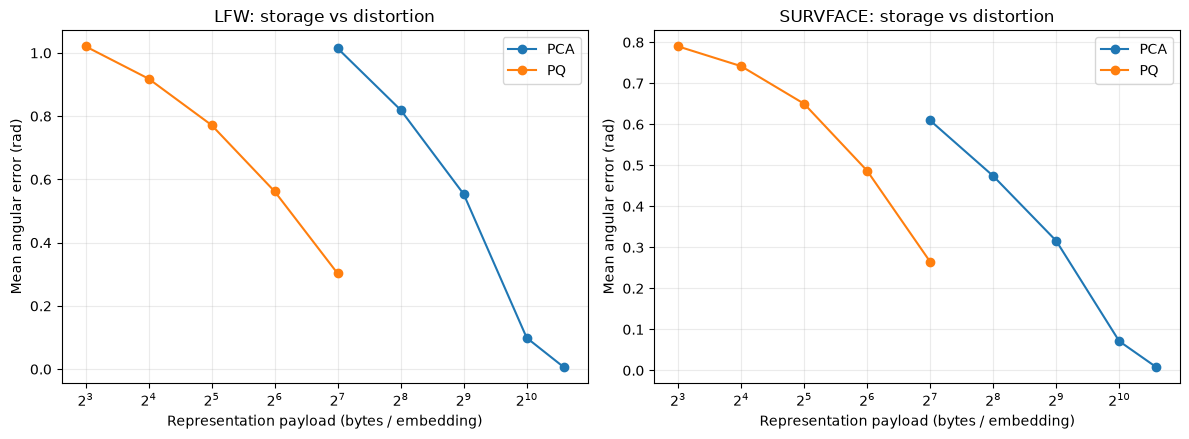

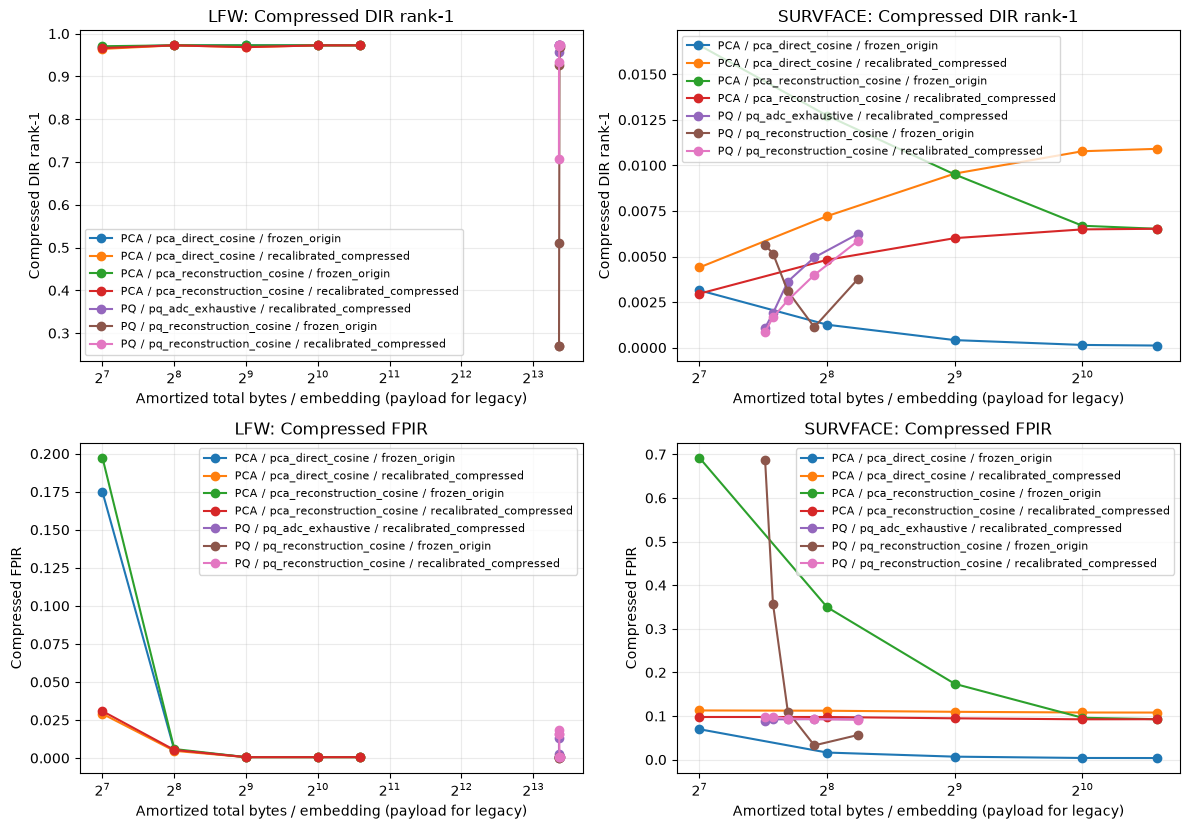

In [13]:
import matplotlib.pyplot as plt

figures = {}
dataset_order = list(DATASETS)

fig_distortion, axes = plt.subplots(
    1, len(dataset_order), figsize=(6 * len(dataset_order), 4.5), squeeze=False
)
geometry = compression_summary_all.drop_duplicates(
    ["dataset", "compression_family", "compression_profile"]
)
for axis, dataset in zip(axes[0], dataset_order):
    subset = geometry.loc[geometry["dataset"].eq(dataset)]
    for family, group in subset.groupby("compression_family", sort=True):
        ordered = group.sort_values("storage_bytes_per_embedding")
        axis.plot(
            ordered["storage_bytes_per_embedding"],
            ordered["mean_angular_error_rad"],
            marker="o",
            label=family.upper(),
        )
    axis.set_xscale("log", base=2)
    axis.set(
        title=f"{dataset.upper()}: storage vs distortion",
        xlabel="Representation payload (bytes / embedding)",
        ylabel="Mean angular error (rad)",
    )
    axis.grid(alpha=0.25)
    axis.legend()
fig_distortion.tight_layout()
figures["storage_distortion"] = fig_distortion

metrics = (
    ("compressed_dir_rank1", "Compressed DIR rank-1"),
    ("compressed_fpir", "Compressed FPIR"),
)
fig_open_set, axes = plt.subplots(
    len(metrics), len(dataset_order),
    figsize=(6 * len(dataset_order), 4.2 * len(metrics)),
    squeeze=False,
)
for column_index, dataset in enumerate(dataset_order):
    subset = compression_summary_all.loc[
        compression_summary_all["dataset"].eq(dataset)
    ]
    for row_index, (metric, ylabel) in enumerate(metrics):
        axis = axes[row_index, column_index]
        for (family, search_mode, policy), group in subset.groupby(
            ["compression_family", "search_mode", "threshold_policy"], sort=True
        ):
            plot_group = group.copy()
            plot_group["plot_storage_bytes"] = pd.to_numeric(
                plot_group["amortized_storage_bytes_per_gallery_template"],
                errors="coerce",
            ).fillna(plot_group["storage_bytes_per_embedding"])
            ordered = plot_group.sort_values("plot_storage_bytes")
            axis.plot(
                ordered["plot_storage_bytes"],
                ordered[metric],
                marker="o",
                label=f"{family.upper()} / {search_mode} / {policy}",
            )
        axis.set_xscale("log", base=2)
        threshold_claim_blocked = bool(
            dataset == "survface"
            and SURVFACE_CALIBRATION_TRANSFER_FAILED is True
        )
        title_suffix = (
            " [DESCRIPTIVE ONLY: calibration transfer failed]"
            if threshold_claim_blocked
            else ""
        )
        axis.set(
            title=f"{dataset.upper()}: {ylabel}{title_suffix}",
            xlabel="Amortized total bytes / embedding (payload for legacy)",
            ylabel=ylabel,
        )
        if threshold_claim_blocked:
            axis.text(
                0.02, 0.02,
                "Not a valid target-FPIR operating-point claim",
                transform=axis.transAxes, color="darkred", fontsize=8,
                bbox={"facecolor": "white", "alpha": 0.8, "edgecolor": "darkred"},
            )
        axis.grid(alpha=0.25)
        axis.legend(fontsize=8)
fig_open_set.tight_layout()
figures["storage_open_set"] = fig_open_set

integrated_columns = [
    "dataset", "model_uid", "run_id", "summary_artifact_type",
    "summary_claim_status", "derived_evaluation_paper_eligible",
    "compression_family",
    "compression_profile", "search_mode", "threshold_policy",
    "compressed_score_space", "compressed_dir_rank1", "compressed_fpir",
    "storage_bytes_per_embedding", "codebook_bytes",
    "gallery_template_count", "compressed_gallery_storage_bytes",
    "amortized_storage_bytes_per_gallery_template",
    "compressed_search_latency_ms_per_query",
    "compressed_search_queries_per_second",
    "accept_to_reject_count", "accept_to_reject_rate",
    "reject_to_accept_count", "reject_to_accept_rate",
]
dir_fpir_storage_latency = compression_summary_all[integrated_columns].copy()
display(dir_fpir_storage_latency)


## 4. SurvFace Grad-CAM faithfulness (3-model matched condition)

ArcFace, AdaFace, MagFace 각각에서 protocol role × raw-norm quartile × target-score quartile로 2,048개를 층화 선택하고 동일한 10% high/low/random occlusion을 적용한 threshold-independent 파생 결과입니다. Strong faithfulness는 high-saliency 가림이 low와 random control보다 모두 큰 경우에만 통과합니다.


In [14]:
SURVFACE_FAITHFULNESS = pd.DataFrame()
SURVFACE_FAITHFULNESS_MANIFEST = None
SURVFACE_FAITHFULNESS_DIR = (
    PROJECT_ROOT / "results/paper/survface/faithfulness_cross_model_v1"
)
if INCLUDE_SURVFACE_FAITHFULNESS and "survface" in DATASETS:
    faithfulness_manifest_path = SURVFACE_FAITHFULNESS_DIR / "manifest.json"
    faithfulness_table_path = (
        SURVFACE_FAITHFULNESS_DIR / "faithfulness_cross_model_primary.csv"
    )
    SURVFACE_FAITHFULNESS_MANIFEST = load_json(faithfulness_manifest_path)
    if SURVFACE_FAITHFULNESS_MANIFEST.get("artifact_type") != (
        "survface_gradcam_faithfulness_cross_model"
    ):
        raise ValueError("unexpected SurvFace faithfulness artifact type")
    if SURVFACE_FAITHFULNESS_MANIFEST.get("threshold_independent") is not True:
        raise ValueError("SurvFace faithfulness must be threshold-independent")
    selected_source_matches = [
        source for source in SURVFACE_FAITHFULNESS_MANIFEST.get("sources", [])
        if source.get("source_run_id") == SELECTED_RUN_IDS["survface"]
        and source.get("model_uid") == MODEL_UIDS["survface"]
    ]
    if len(selected_source_matches) != 1:
        print(
            "WARNING: selected SurvFace run/model is absent from the "
            "cross-model faithfulness artifact; faithfulness is excluded."
        )
        SURVFACE_FAITHFULNESS_MANIFEST = None
    else:
        output_entry = next(
            entry for entry in SURVFACE_FAITHFULNESS_MANIFEST["outputs"]
            if entry["path"] == faithfulness_table_path.name
        )
        if sha256_file(faithfulness_table_path) != output_entry["sha256"]:
            raise ValueError("SurvFace faithfulness table SHA-256 mismatch")
        SURVFACE_FAITHFULNESS = pd.read_csv(faithfulness_table_path)
        if set(SURVFACE_FAITHFULNESS["model_family"]) != {
            "arcface", "adaface", "magface"
        }:
            raise ValueError("SurvFace faithfulness requires all three FR models")
display(SURVFACE_FAITHFULNESS)


,model_family,model_uid,source_run_id,faithfulness_gain_over_low_saliency__mean,faithfulness_gain_over_random__mean,high_saliency_occlusion_score_drop__mean,low_saliency_occlusion_score_drop__mean,random_occlusion_score_drop__mean,faithfulness_gain_over_low_saliency__mean_ci_lower,faithfulness_gain_over_random__mean_ci_lower,...,low_saliency_occlusion_score_drop__mean_ci_upper,random_occlusion_score_drop__mean_ci_upper,faithfulness_gain_over_low_saliency__positive_fraction,faithfulness_gain_over_random__positive_fraction,high_saliency_occlusion_score_drop__positive_fraction,low_saliency_occlusion_score_drop__positive_fraction,random_occlusion_score_drop__positive_fraction,passes_high_over_low,passes_high_over_random,passes_strong_faithfulness
0,adaface,adaface-4df25b75e065b0b9ed43,20260731-R001-8f94ec62,0.084361,-0.075585,0.105813,0.021452,0.181398,0.079480,-0.080728,...,0.024026,0.187063,0.794922,0.240234,0.879395,0.642090,0.949707,True,False,False
1,arcface,arcface-7972a704552df378345f,20260803-R001-33efcd08,0.058971,-0.024210,0.090267,0.031296,0.114478,0.054593,-0.028484,...,0.034046,0.118517,0.737305,0.393066,0.854980,0.696777,0.904297,True,False,False
2,magface,magface-6931178ad2025e1b3799,20260802-R001-9bccb0c1,-0.092902,-0.119991,0.097094,0.189997,0.217085,-0.097835,-0.124602,...,0.194709,0.221077,0.192871,0.112305,0.887207,0.966797,0.990234,False,False,False


## 5. 공통 CSV·그림·manifest 저장

공통 출력에는 compact table과 그림만 기록합니다. `dir_fpir_storage_latency.csv`는 검색 모드별 DIR·FPIR·Storage·Latency를 한 표에 두며, source summary manifest의 SHA-256을 별도 manifest에 기록합니다.


In [15]:
from datetime import datetime, timezone

selection_tag = "__".join(
    f"{dataset}-{SELECTED_RUN_IDS[dataset]}" for dataset in DATASETS
)
COMMON_OUTPUT_DIR = (
    PROJECT_ROOT / "results" / "paper" / "common" / MODEL_NAME / selection_tag
)
export_result = {
    "status": "computed_not_written",
    "destination": COMMON_OUTPUT_DIR.relative_to(PROJECT_ROOT).as_posix(),
    "compression_summary_all_rows": int(len(compression_summary_all)),
}

if WRITE_OUTPUTS:
    COMMON_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    output_paths = {
        "compression_summary_all.csv": COMMON_OUTPUT_DIR / "compression_summary_all.csv",
        "retrieval_summary_all.csv": COMMON_OUTPUT_DIR / "retrieval_summary_all.csv",
        "dir_fpir_storage_latency.csv": COMMON_OUTPUT_DIR / "dir_fpir_storage_latency.csv",
        "storage_distortion.png": COMMON_OUTPUT_DIR / "storage_distortion.png",
        "storage_open_set.png": COMMON_OUTPUT_DIR / "storage_open_set.png",
    }
    if not SURVFACE_FAITHFULNESS.empty:
        output_paths["survface_faithfulness_cross_model.csv"] = (
            COMMON_OUTPUT_DIR / "survface_faithfulness_cross_model.csv"
        )
    existing = [path for path in output_paths.values() if path.exists()]
    manifest_path = COMMON_OUTPUT_DIR / "cross_dataset_summary_manifest.json"
    if manifest_path.exists():
        existing.append(manifest_path)
    if existing and not OVERWRITE_COMMON_OUTPUTS:
        raise FileExistsError(
            f"공통 출력이 이미 있습니다. OVERWRITE_COMMON_OUTPUTS=True가 필요합니다: {existing}"
        )

    compression_summary_all.to_csv(
        output_paths["compression_summary_all.csv"],
        index=False,
        encoding="utf-8",
        lineterminator="\n",
        float_format="%.12g",
    )
    retrieval_summary_all.to_csv(
        output_paths["retrieval_summary_all.csv"],
        index=False,
        encoding="utf-8",
        lineterminator="\n",
        float_format="%.12g",
    )
    dir_fpir_storage_latency.to_csv(
        output_paths["dir_fpir_storage_latency.csv"],
        index=False,
        encoding="utf-8",
        lineterminator="\n",
        float_format="%.12g",
    )
    if not SURVFACE_FAITHFULNESS.empty:
        SURVFACE_FAITHFULNESS.to_csv(
            output_paths["survface_faithfulness_cross_model.csv"],
            index=False,
            encoding="utf-8",
            lineterminator="\n",
            float_format="%.12g",
        )
    figures["storage_distortion"].savefig(
        output_paths["storage_distortion.png"], dpi=180, bbox_inches="tight"
    )
    figures["storage_open_set"].savefig(
        output_paths["storage_open_set.png"], dpi=180, bbox_inches="tight"
    )

    common_manifest = {
        "schema_version": 4,
        "artifact_type": "cross_dataset_compact_summary",
        "generated_at_utc": datetime.now(timezone.utc).isoformat(),
        "model_name": MODEL_NAME,
        "datasets": list(DATASETS),
        "survface_threshold_claim_status": (
            "blocked_calibration_transfer"
            if SURVFACE_CALIBRATION_TRANSFER_FAILED is True
            else "not_flagged"
        ),
        "selected_runs": {
            dataset: {
                "run_id": SELECTED_RUN_IDS[dataset],
                "model_uid": MODEL_UIDS[dataset],
                "summary_artifact_type": SUMMARY_MANIFESTS[dataset]["artifact_type"],
                "summary_claim_status": SUMMARY_MANIFESTS[dataset].get(
                    "claim_status", "legacy_source_run"
                ),
                "summary_manifest": {
                    "path": (
                        SUMMARY_DIRS[dataset] / "summary_manifest.json"
                    ).relative_to(PROJECT_ROOT).as_posix(),
                    "sha256": sha256_file(
                        SUMMARY_DIRS[dataset] / "summary_manifest.json"
                    ),
                },
            }
            for dataset in DATASETS
        },
        "survface_faithfulness": (
            {
                "included": True,
                "claim_status": SURVFACE_FAITHFULNESS_MANIFEST["claim_status"],
                "paper_eligible": SURVFACE_FAITHFULNESS_MANIFEST["paper_eligible"],
                "threshold_independent": True,
                "strong_faithfulness_pass_count": (
                    SURVFACE_FAITHFULNESS_MANIFEST["strong_faithfulness_pass_count"]
                ),
                "source_manifest": {
                    "path": (
                        SURVFACE_FAITHFULNESS_DIR / "manifest.json"
                    ).relative_to(PROJECT_ROOT).as_posix(),
                    "sha256": sha256_file(
                        SURVFACE_FAITHFULNESS_DIR / "manifest.json"
                    ),
                },
            }
            if SURVFACE_FAITHFULNESS_MANIFEST is not None
            else {"included": False}
        ),
        "join_contract": {
            "grain": (
                "one row per dataset, model, run, compression profile, "
                "search mode, and threshold policy"
            ),
            "validation": "compression one-to-retrieval many",
            "rows": int(len(compression_summary_all)),
        },
        "output_files": {
            name: {
                "path": path.relative_to(PROJECT_ROOT).as_posix(),
                "bytes": path.stat().st_size,
                "sha256": sha256_file(path),
            }
            for name, path in output_paths.items()
        },
    }
    manifest_path.write_text(
        json.dumps(common_manifest, ensure_ascii=False, indent=2, sort_keys=True)
        + "\n",
        encoding="utf-8",
        newline="\n",
    )
    export_result = {
        "status": "written",
        "destination": COMMON_OUTPUT_DIR.relative_to(PROJECT_ROOT).as_posix(),
        "manifest": manifest_path.relative_to(PROJECT_ROOT).as_posix(),
        "compression_summary_all_rows": int(len(compression_summary_all)),
        "retrieval_summary_all_rows": int(len(retrieval_summary_all)),
    }
export_result


{'status': 'written',
 'destination': 'results/paper/common/arcface/lfw-20260803-R001-a4479011__survface-20260803-R001-33efcd08',
 'manifest': 'results/paper/common/arcface/lfw-20260803-R001-a4479011__survface-20260803-R001-33efcd08/cross_dataset_summary_manifest.json',
 'compression_summary_all_rows': 70,
 'retrieval_summary_all_rows': 70}

## Final check

- `MODEL_UIDS`와 실제 workflow `RUN_IDS`를 혼동하지 않습니다.
- `origin_fallback_count`가 0이 아닌 summary는 결합하지 않습니다.
- source ledger의 `origin_fallback_used`는 compact summary에서 `origin_fallback_count=0`으로 재검증합니다.
- `origin_decision_threshold`와 `compressed_decision_threshold`를 분리 보존합니다.
- PCA direct/reconstruction과 PQ reconstruction/ADC는 `search_mode`로 분리합니다.
- `search_space_v3_matched_calibration`은 training 3,000-ID half-gallery와 non-mated-only threshold를 사용하며 완료 source run을 불변으로 보존합니다.
- threshold crossing은 `Accept→Reject`와 `Reject→Accept`를 별도 열로 기록합니다.
- PQ ADC에는 cosine frozen-origin threshold를 적용하지 않으며 ADC-space 재보정 결과만 허용합니다.
- SurvFace origin audit가 target FPIR transfer 실패를 표시하면 threshold-dependent 논문 주장은 보류합니다.
- SurvFace Grad-CAM faithfulness는 threshold-independent 3-model high/low/random control 표로 분리하며, 현재 strong criterion 통과 모델 수를 manifest에 기록합니다.
- `compression_summary_all.csv`는 compact summary만 포함하며 대용량 query/sample ledger를 복제하지 않습니다.
- `dir_fpir_storage_latency.csv`는 DIR·FPIR·payload/codebook 상각 저장량·관측 latency를 한 표에 기록합니다.
- LFW와 SurvFace의 protocol·목표 FPIR 차이 때문에 절대 DIR/FPIR를 동일 난이도로 직접 비교하지 않습니다.
- `VERIFY_SOURCE_SHA256=True`는 수 GB 원본 전체를 다시 읽으므로 최종 보존 검증 시에만 사용합니다.
